<a href="https://colab.research.google.com/github/TasnimTamanna02/Spam-SMS-Detection-/blob/main/SpamSMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam SMS Detection

In [ ]:
import pandas as pd
import numpy as np

## Dataset Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**First I will observe the content of the file before importing it.**

In [ ]:
!head -n 5 "/content/drive/MyDrive/Portfolio/Datasets/sms+spam+collection/SMSSpamCollection"

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Portfolio/Datasets/sms+spam+collection/SMSSpamCollection', sep='\t', names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


**Now the raw text data is converted to dataframe with two separate columns: Label and Messages.**

Next we need to check for missing of duplicate records.

## Data Cleaning

In [ ]:
#missing values
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [ ]:
#duplicate rows
print(df.duplicated().sum())

403


In [ ]:
df.drop_duplicates(keep='first', inplace=True)
df.shape

(5169, 2)

**No missing values; 403 duplicates has been found and removed.**

Next step is preprocessing the data for model training.

## Data Preprocessing

### Text Formatting

In [ ]:
import nltk
import string
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
punctuation_set = set(string.punctuation)

In [ ]:
def clean_text(text):
  text = text.lower()
  text = "".join([char for char in text if char not in punctuation_set])
  text = " ".join([word for word in text.split() if word not in stop_words])

  return text

In [ ]:
df['message'] = df['message'].apply(clean_text)
df.head()

,label,message
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,u dun say early hor u c already say
4,ham,nah dont think goes usf lives around though


### Label Encoding

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though


### Train-Test-Split

Train-test-split must be performed before vectorization to prevent data leakage

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df['message']
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**Dataset is split into 80% train set and 20% test set**

### Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()

x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)

In [ ]:
print(f"Training data shape after TF-IDF: {x_train.shape}")
print(f"Testing data shape after TF-IDF: {x_test.shape}")

Training data shape after TF-IDF: (4135, 8151)
Testing data shape after TF-IDF: (1034, 8151)


## Model Training

### Naive Bayes

In [ ]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
cnb = ComplementNB()
cnb.fit(x_train, y_train)

ComplementNB()

In [ ]:
cnb_pred = cnb.predict(x_test)

In [ ]:
print(f"Complement Naive Bayes Accuracy: {accuracy_score(y_test, cnb_pred):.2%}\n")
print(classification_report(y_test, cnb_pred, target_names=['Ham', 'Spam']))

Complement Naive Bayes Accuracy: 95.94%

              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       894
        Spam       0.81      0.91      0.86       140

    accuracy                           0.96      1034
   macro avg       0.90      0.94      0.92      1034
weighted avg       0.96      0.96      0.96      1034



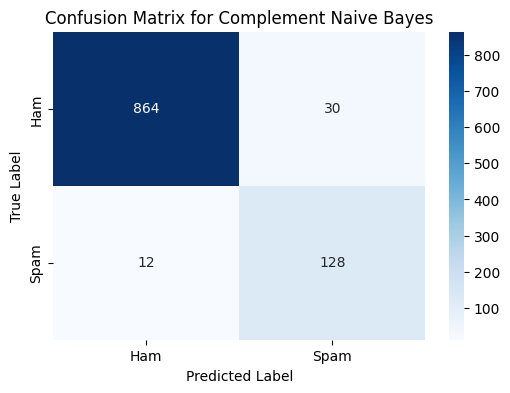

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, cnb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Complement Naive Bayes')
plt.show()

While it's a good job in identifying spams, it's sending **too many real messages into spam**. That would be a nuisance.

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lgr = LogisticRegression(max_iter=1000)
lgr.fit(x_train, y_train)

lgr_pred = lgr.predict(x_test)

In [ ]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lgr_pred):.2%}\n")
print(classification_report(y_test, lgr_pred, target_names=['Ham', 'Spam']))

Logistic Regression Accuracy: 95.84%

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       894
        Spam       0.96      0.72      0.82       140

    accuracy                           0.96      1034
   macro avg       0.96      0.86      0.90      1034
weighted avg       0.96      0.96      0.96      1034



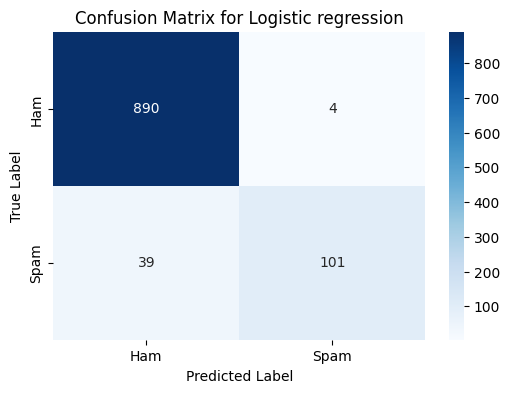

In [ ]:
cm = confusion_matrix(y_test, lgr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic regression')
plt.show()

A whole opposite fail from NB. It's **missing a lot of spam messages**.

### Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm = LinearSVC(dual=False, random_state=10)
svm.fit(x_train, y_train)

svm_pred = svm.predict(x_test)

In [ ]:
print(f"Linear SVM Accuracy: {accuracy_score(y_test, svm_pred):.2%}\n")
print(classification_report(y_test, svm_pred, target_names=['Ham', 'Spam']))

Linear SVM Accuracy: 97.97%

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       894
        Spam       0.95      0.89      0.92       140

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



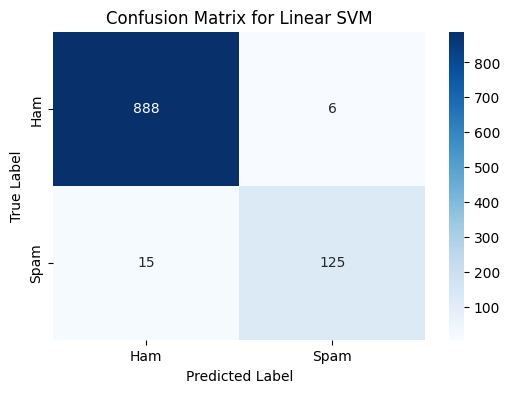

In [ ]:
cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Linear SVM')
plt.show()

LinearSVM is giving a **very good balance.** And it's sending very little real ham messages into spam. **Approved!**

### MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=10)
mlp.fit(x_train, y_train)

mlp_pred = mlp.predict(x_test)

In [ ]:
print(f"MLP (Neural Network) Accuracy: {accuracy_score(y_test, mlp_pred):.2%}\n")
print(classification_report(y_test, mlp_pred, target_names=['Ham', 'Spam']))

MLP (Neural Network) Accuracy: 98.16%

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       894
        Spam       0.95      0.91      0.93       140

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



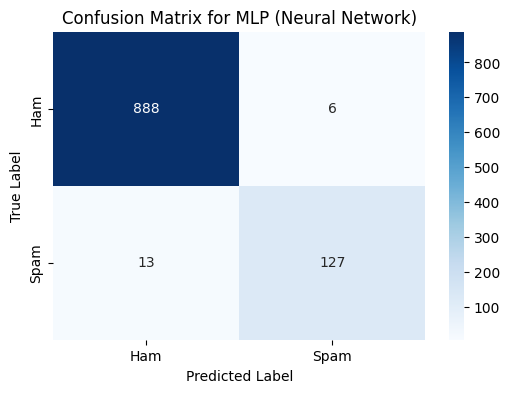

In [ ]:
cm_mlp = confusion_matrix(y_test, mlp_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MLP (Neural Network)')
plt.show()

Pretty similar to SVM's performance, a little better in spam prediction (by 2 messages).

## Final Verdict



*   Naive Bayes and Logistic Regression both have bias and unbalanced performance between Ham and Spam detection
*   Linear SVM and MLP shows an almost identically well-balanced, high performance.

*   MLP performs a little bit better in detecting spam (2 messages), but it is not worth the high memory and time cost and black-box complexity.


**Linear SVM is the best overall model for this spam message detection project.**





## Testing the Pipeline (with custom input message)

Following the training pipeline, I will create **a custom function** that takes a message as input and delivers a prediction of whether it's a spam or not.

In [ ]:
def predict_spam(message):
    cleaned_msg = clean_text(message)
    vectorized_msg = tfidf.transform([cleaned_msg])

    prediction = svm.predict(vectorized_msg)[0]

    if prediction == 1:
        print(f"SPAM DETECTED! \nMessage: \"{message}\"\n")
    else:
        print(f"Not Spam. \nMessage: \"{message}\"\n")

In [ ]:
message = input("Enter a message/sms: ")
predict_spam(message)

Enter a message/sms: Heeeey! R U cming??
Not Spam. 
Message: "Heeeey! R U cming??"



In [ ]:
message = input("Enter a message/sms: ")
predict_spam(message)

Enter a message/sms: Congrats! U w1n a phn!
Not Spam. 
Message: "Congrats! U w1n a phn!"



In [ ]:
message = input("Enter a message/sms: ")
predict_spam(message)

Enter a message/sms: Congrats! U have win a phone!
SPAM DETECTED! 
Message: "Congrats! U have win a phone!"



In [ ]:
message = input("Enter a message/sms: ")
predict_spam(message)

Enter a message/sms: SALE! Buy 1 Get 1 Free!
Not Spam. 
Message: "SALE! Buy 1 Get 1 Free!"



**Observations:**
While the model showed high accuracy in test set, it is struggling to detect obvious spam messages for direct user input. Next, I will check the list of unique words (among the 8151 words picked from training set) that are assigned as spam.

## Debugging

In [ ]:
features = tfidf.get_feature_names_out()

In [ ]:
svm_coeff = svm.coef_[0]

word_weights = pd.DataFrame({
    'Word': features,
    'Weight': svm_coeff
})

spam = word_weights[word_weights['Weight'] > 0].sort_values(by='Weight', ascending=False)
print(len(spam))

2663


In [ ]:
print(spam.head(50).to_string(index=False))

       Word   Weight
        txt 2.297933
      claim 2.204660
     mobile 1.977893
    service 1.725641
       stop 1.724914
      reply 1.688410
        win 1.599036
   ringtone 1.476181
         18 1.422522
      prize 1.367579
        500 1.348126
       text 1.326686
     urgent 1.323773
       chat 1.308900
      88066 1.306962
      apply 1.273352
    content 1.208706
07090201529 1.201825
information 1.197792
        150 1.183856
       link 1.179337
   services 1.158156
        wap 1.146930
       club 1.135407
       tone 1.132090
       rate 1.096396
         16 1.070206
     dating 1.064027
       sexy 1.060871
      tones 1.060216
       150p 1.051672
     10pmin 1.026964
        bid 1.015200
   landline 0.997984
       cash 0.992078
        new 0.991639
       free 0.986972
      calls 0.984735
    credits 0.977898
       txts 0.960525
      150pm 0.956968
        mob 0.948648
    voucher 0.943230
    freemsg 0.933133
        250 0.928236
  voicemail 0.927012
        per 0

In [ ]:
spam.to_csv('spam_words_list.csv', index=False)

**The cutoff line of Linear SVM between Ham and Spam is set at 0, and all positive weighted words are in the spam zone.**


Observing the list explains why the model struggled to detect spam messages twice.



*   ***Congrats! U w1n a phn!***

Although 'win' has a extremely high positive value, changing to 'w1n' makes it a completely different word that isn't part of the model's list

*   ***SALE! Buy 1 Get 1 Free!***

First, 'free' has only 0.987 weight and sale is not within top 50, meaning much smaller weight. Second, the `clean_text` function removes 'get' as part of the stop-word list. Third, the vectorization method ignores single digits like '1'. which renders the sentence into 'sale buy free', which doesn't appear as spam to model.

It can be handled in **two ways**-

1.   *Reducing Over-preprocessing:* removing the stop-word elimination and letting the vectorizer include single digits.
2.   *Text Normalization:* replacing common substitutions (1 --> i, 3-->e, 0-->o etc.) before vectorization.



**In Ver.2**
